# (노트) 단순선형회귀 with 텐서플로

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [데이터과학]

### 로드맵

`-` 오늘수업내용: 단순선형회귀 

`-` 단순선형회귀를 왜 배우는가? 
- 우리가 궁극적으로 배우고싶은것: 심층신경망 DNN $\to$ 합성곱신경망 CNN $\to$ 적대적생성신경망 GAN 
- 심층신경망을 바로 이해하기는 어려움 
- 다음의 과정으로 이해해야함: (선형대수학 $\to$) 회귀분석 $\to$ 로지스틱회귀분석 $\to$ 심층신경망

### 선형회귀

`-` 상황극 
- 나는 동네에 커피점을 차렸다. 
- 장사를 하다 보니까 날이 더울수록 아이스아메카노의 판매량이 증가한다는 사실을 깨달았다. 
- 일기예보는 미리 나와있으니까 그 정보를 잘 이용하면 `온도 -> 아아 판매량 예측` 이 가능할 듯 하다. (내가 앞으로 얼마나 벌지 예측가능하다는 의미) 

`-` 가짜자료 생성 

In [62]:
import matplotlib.pyplot as plt
import tensorflow as tf

`-` 온도 ${\bf x}$가 아래와 같다고 하자. 

In [4]:
x=tf.constant([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4]) # 기온
x

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4],
      dtype=float32)>

`-` 아이스아메리카노의 판매량 ${\bf y}$는 아래의 식을 따른다고 하자. (판매량은 정수로 나오겠지만 그냥 소수점도 가능하다고 생각하자)

$$ {\bf y} \approx 10.2 + 2.2 {\bf x} $$ 

- 여기에서 10.2, 2.2 라는 숫자는 제가 임의로 정한것입니다. 
- 식의 의미: 온도가 0도일 경우 아이스아메리카노는 대략 10.2잔정도 팔림 + 온도가 1도 증가할때마다 2.2잔씩 더 팔림. 
- 물결의 의미: 현실반영. 세상에는 수식대로 되지 않고 약간의 운이 존재함. 

In [5]:
tf.random.set_seed(43052)
epsilon=tf.random.normal([10]) # 운적인 요소 
epsilon

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 0.9983651 , -0.8457241 ,  1.090825  ,  0.85255873, -0.7729972 ,
       -1.724309  , -0.5929508 ,  1.1765009 ,  0.42130336,  0.76988286],
      dtype=float32)>

In [6]:
y=10.2 + 2.2*x + epsilon # 아이스아메카노 판매량
y

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([55.418365, 58.194283, 61.230827, 62.312557, 63.107002, 63.69569 ,
       67.247055, 71.4365  , 73.1013  , 77.84988 ], dtype=float32)>

`-` 즉 우리는 아래와 같은 자료를 모았다고 생각하자 .

In [7]:
tf.transpose(tf.concat([[x],[y]],0))

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[20.1     , 55.418365],
       [22.2     , 58.194283],
       [22.7     , 61.230827],
       [23.3     , 62.312557],
       [24.4     , 63.107002],
       [25.1     , 63.69569 ],
       [26.2     , 67.247055],
       [27.3     , 71.4365  ],
       [28.4     , 73.1013  ],
       [30.4     , 77.84988 ]], dtype=float32)>

`-` 그려보자. 

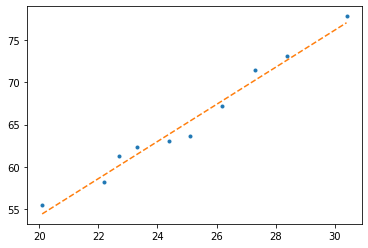

In [8]:
plt.plot(x,y,'.') # 점, 관측치 
plt.plot(x,10.2 + 2.2*x ,'--') # 주황색선, 세상의 법칙 

`-` 우리의 목표: 파란색점 $\to$ 주황색선 추론 // 데이터를 바탕으로 세상의 법칙을 추론 

`-` 아이디어: 데이터를 보니까 x와 y는 선형의 관계인것 처럼 보인다. 즉 적당한 $a,b$를 찾으면 모든 $i=1,2,\dots,10$에 대하여 아래가 만족할것 같다. 

$y_i \approx ax_i +b$ 

$y_i \approx \beta_0 + \beta_1 x_i$ 

`-` 짐작으로 $a$, $b$를 알아내보자. 

데이터를 살펴보자.. 

In [10]:
tf.transpose(tf.concat([[x],[y]],0))

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[20.1     , 55.418365],
       [22.2     , 58.194283],
       [22.7     , 61.230827],
       [23.3     , 62.312557],
       [24.4     , 63.107002],
       [25.1     , 63.69569 ],
       [26.2     , 67.247055],
       [27.3     , 71.4365  ],
       [28.4     , 73.1013  ],
       [30.4     , 77.84988 ]], dtype=float32)>

적당히 `왼쪽*2+15=오른쪽` 의 관계가 성립하는듯 하다. 

따라서 $a=2, b=15$ 혹은 $\beta_0=15, \beta_1=2$로 추론할 수 있겠다. 

`-` 누군가가 $(\beta_0,\beta_1)=(16,2)$ 이라고 주장할 수도 있다. (어차피 지금은 감으로 찍는거 아닌가?)

`-` 새로운 주장으로 인하여 $(\beta_0,\beta_1)=(15,2)$로 볼 수도 있고 $(\beta_0,\beta_1)=(14,2)$로 볼 수도 있어졌다. 이중에서 어떤 추정치가 좋을까? 

- 후보1: $(\beta_0,\beta_1)=(15,2)$ 
- 후보2: $(\beta_0,\beta_1)=(14,2)$ 

`-` 가능한 $y_i \approx \beta_0 + \beta_1 x_i$ 이 되도록 만드는 $(\beta_0,\beta_1)$이 좋을 것이다. $\to$ 후보1,2를 비교해보자. 

(관찰에 의한 비교) 

후보1에 $i=1,2$를 넣고 관찰하여보자. 

In [23]:
20.1*2 + 15, 55.418365 # i=1

(55.2, 55.418365)

In [24]:
22.2*2 + 15, 58.194283 # i=2

(59.4, 58.194283)

후보2를 $i=1,2$에 넣고 관찰하여보자. 

In [21]:
20.1*2 + 14, 55.418365 # i=1

(54.2, 55.418365)

In [22]:
22.2*2 + 14, 58.194283 # i=2

(58.4, 58.194283)

$i=1$인 경우에는 후보1이 $i=2$인 경우에는 후보2가 더 잘맞는것 같다. 

(좀 더 체계적인비교)

$i=1,2,\dots,10$ 에서 후보1이 좋은지 후보2가 좋은지 종합적으로 비교하려면? 

후보1, 2에 대하여 $\sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2$의 값을 비교해보자. 

In [25]:
sum1=0
for i in range(10):
    sum1=sum1+(y[i]-15-2*x[i])**2

In [26]:
sum2=0
for i in range(10):
    sum2=sum2+(y[i]-14-2*x[i])**2

In [27]:
sum1,sum2

(<tf.Tensor: shape=(), dtype=float32, numpy=14.734169>,
 <tf.Tensor: shape=(), dtype=float32, numpy=31.521086>)

후보1이 종합적으로 더 좋다. 이 과정을 무한번 반복하면 최적의 추정치를 찾을 수 있다. 

`-` 그런데 현실적으로 구현하기 힘든 알고리즘이다. (무한번 계산하기가 힘들기도 하고, 언제 멈출지도 애매함) 

`-` 수학을 이용하여 좀 더 체계적으로 찾아보자. 결국 아래값을 최소화하는 $\beta_0, \beta_1$을 찾으면 된다. 

$\sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2$ 

그런데 위의식을 풀면 $\beta_0$, $\beta_1$에 대한 2차식이다. (여기에서 $x_i, y_i$는 모두 값을 아는 상수임, 변수는 $\beta_0,\beta_1$ 뿐이다.) 

결국 이차식의 최소값을 구하는 문제로 귀결되므로 아래를 연립하여 풀면된다. 

$\begin{cases}
\frac{\partial}{\partial \beta_0} \sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2 =0  \\ 
\frac{\partial}{\partial \beta_1} \sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2 =0 
\end{cases}$

`-` 풀어보자. 

$\begin{cases}
\sum_{i=1}^{10}2(y_i-\beta_0-\beta_1x_i) =0  \\ 
\sum_{i=1}^{10}2x_i(y_i-\beta_0-\beta_1x_i) =0 
\end{cases}$

정리하면 아래와 같이 나온다. 

- $\hat{\beta}_0=\bar{y}-\hat{\beta}_1 \bar{x}$

- $\hat{\beta}_1=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^n(x_i-\bar{x})^2}=\frac{S_{xy}}{S_{xx}}$ 

`-` 따라서 최적의 추정치 $(\hat{\beta}_0, \hat{\beta}_1)$를 이용한 추세선은 아래와 같이 구할 수 있음 

In [38]:
Sxx=sum((x-sum(x)/10)**2)
Sxx

<tf.Tensor: shape=(), dtype=float32, numpy=87.84898>

In [39]:
Sxy=sum((y-sum(y)/10)*(x-sum(x)/10))
Sxy

<tf.Tensor: shape=(), dtype=float32, numpy=194.64737>

In [40]:
beta1_estimated = Sxy/Sxx
beta1_estimated

<tf.Tensor: shape=(), dtype=float32, numpy=2.2157042>

In [41]:
beta0_estimated = sum(y)/10-sum(x)/10*beta1_estimated
beta0_estimated

<tf.Tensor: shape=(), dtype=float32, numpy=9.94458>

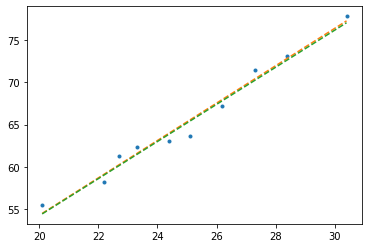

In [42]:
plt.plot(x,y,'.')
plt.plot(x,beta0_estimated+ beta1_estimated*x,'--')
plt.plot(x,10.2+ 2.2*x,'--')

> Note: 샘플수가 커질수록 초록색선은 점점 주황색선으로 가까워진다. 

`-` 꽤 훌륭한 도구임. 그런데 약간의 단점이 존재한다. 

(1) 공식이 조금 복잡함.. 

(2) 변수가 여러개일경우 확장이 어려움 

`-` 우리가 했던 논의를 매트릭스 버전으로 바꾸면 위의 단점들이 극복가능하다. 

`-` 모형의 매트릭스화 

우리의 모형은 아래와 같다. 

$y_i=\beta_0 + \beta_1 x_i +\epsilon_i, \quad i=1,2,\dots, 10$


풀어서 쓰면 

$\begin{cases}
y_1 = \beta_0 +\beta_1 x_1 + \epsilon_1 \\ 
y_2 = \beta_0 +\beta_1 x_2 + \epsilon_2 \\ 
\dots \\ 
y_{10} = \beta_0 +\beta_1 x_{10} + \epsilon_{10} 
\end{cases}$

아래와 같이 쓸 수 있다. 

$\begin{bmatrix} 
y_1 \\ 
y_2 \\ 
\dots \\
y_{10} 
\end{bmatrix} 
= \begin{bmatrix} 
1 & x_1 \\ 
1 & x_2 \\ 
\dots & \dots \\
1 & x_{10} 
\end{bmatrix}\begin{bmatrix}\beta_0 \\ \beta_1 \end{bmatrix} + \begin{bmatrix} 
\epsilon_1 \\ 
\epsilon_2 \\ 
\dots \\
\epsilon_{10} 
\end{bmatrix} $

벡터와 매트릭스 형태로 정리하면 

${\bf y} = {\bf X} \boldsymbol{\beta} + \boldsymbol{\epsilon}$

`-` 손실함수의 매트릭스화:  우리가 최소화 하고싶은었던 식은 아래였다. 

$loss=\sum_{i=1}^{n} (y_i-\beta_0-\beta_1 x_i)^2$

이것역시 벡터표현으로 쓰면 아래와 같다. 

$loss=\sum_{i=1}^{n}(y_i-\beta_0-\beta_1 x_i)^2=({\bf y}-{\bf X}{\boldsymbol \beta})^\top({\bf y}-{\bf X}{\boldsymbol \beta}) $

풀어보면 

$loss={\bf y}^\top {\bf y} - {\bf y}^\top {\bf X}{\boldsymbol\beta} - {\boldsymbol\beta}^\top {\bf X}^\top {\bf y} + {\boldsymbol\beta}^\top {\bf X}^\top {\bf X} {\boldsymbol\beta}$ 

`-` 미분하는 과정의 매트릭스화: 

loss를 최소화하는 $\boldsymbol{\beta}$를 구해야 하므로 loss를 $\boldsymbol{\beta}$로 미분한식을 0이라 놓고 풀면 된다. 

$\frac{\partial}{\partial \boldsymbol{\beta}} loss = \frac{\partial}{\partial \boldsymbol{\beta}} {\bf y}^\top {\bf y} - \frac{\partial}{\partial \boldsymbol{\beta}} {\bf y}^\top {\bf X}{\boldsymbol\beta} - \frac{\partial}{\partial \boldsymbol{\beta}} {\boldsymbol\beta}^\top {\bf X}^\top {\bf y} + \frac{\partial}{\partial \boldsymbol{\beta}} {\boldsymbol\beta}^\top {\bf X}^\top {\bf X} {\boldsymbol\beta}$ 

$=0-{\bf X}^\top {\bf y} - {\bf X}^\top {\bf y} + 2{\bf X}^\top {\bf X} {\boldsymbol \beta}$ 

따라서 $\frac{\partial}{\partial \boldsymbol{\beta}} loss = 0$ 을 풀면 아래와 같다. 

$\boldsymbol{\hat{\beta}}=\bf (X^\top X)^{-1}X^\top y  $

`-` 공식의 매트릭스화: $\boldsymbol{\hat{\beta}}=\bf (X^\top X)^{-1}X^\top y  $ <-- 외우세요!!

`-` 적용해보자. 

In [55]:
X=tf.transpose(tf.concat([[tf.constant([1.0]*10)],[x]],0))
X

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[ 1. , 20.1],
       [ 1. , 22.2],
       [ 1. , 22.7],
       [ 1. , 23.3],
       [ 1. , 24.4],
       [ 1. , 25.1],
       [ 1. , 26.2],
       [ 1. , 27.3],
       [ 1. , 28.4],
       [ 1. , 30.4]], dtype=float32)>

In [56]:
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

In [58]:
X=tf.concat([[tf.constant([1.0]*10)],[x]],0).T
X

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[ 1. , 20.1],
       [ 1. , 22.2],
       [ 1. , 22.7],
       [ 1. , 23.3],
       [ 1. , 24.4],
       [ 1. , 25.1],
       [ 1. , 26.2],
       [ 1. , 27.3],
       [ 1. , 28.4],
       [ 1. , 30.4]], dtype=float32)>

In [59]:
tf.linalg.inv(X.T @ X) @ X.T @ y

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([9.945171, 2.215677], dtype=float32)>

`-` 잘 구해진다. 

`-` 그런데.. 

In [61]:
beta0_estimated,beta1_estimated

(<tf.Tensor: shape=(), dtype=float32, numpy=9.94458>,
 <tf.Tensor: shape=(), dtype=float32, numpy=2.2157042>)

값이 좀 다르다..? 

`-` 같은값입니다! 신경쓰지 마세요! 텐서플로우가 좀 대충 계산합니다. 

In [63]:
import tensorflow.experimental.numpy as tnp

In [64]:
x=tnp.array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4])
y=10.2 + 2.2*x + epsilon

In [68]:
beta1_estimated = sum((x-sum(x)/10)*(y-sum(y)/10))/ sum((x-sum(x)/10)*(x-sum(x)/10))
beta0_estimated = tnp.mean(y) - beta1_estimated* tnp.mean(x)

In [69]:
beta0_estimated,beta1_estimated

(<tf.Tensor: shape=(), dtype=float64, numpy=9.944573243234004>,
 <tf.Tensor: shape=(), dtype=float64, numpy=2.215704607783491>)

In [70]:
X=tnp.concatenate([[tnp.array([1.0]*10)],[x]],0).T
tf.linalg.inv(X.T @ X) @ X.T @ y

<tf.Tensor: shape=(2,), dtype=float64, numpy=array([9.94457324, 2.21570461])>

### 앞으로 할 것 

`-` 선형대수학의 미분이론.. 

`-` 실습 (tensorflow에서 매트릭스를 자유롭게 다루기) 